# DeepXDE - Tutorial 03 - PINN Training

This notebook reproduces the core steps of Tutorial 03 using DeepXDE: define the 1D heat equation, set BC/IC, build a PINN, train, and evaluate.

## 1) Imports and Backend

In [83]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

# Optional: choose backend (baseline uses PyTorch)
# dde.backend.set_default_backend("pytorch")  # or "tensorflow"

# Reproducibility
dde.config.set_random_seed(128)
np.random.seed(128)

## 2) Geometry and Time Domain

In [84]:
# Spatial domain x in [-1, 1], time domain t in [0, 0.6]
geom = dde.geometry.Interval(-1.0, 1.0)
timedomain = dde.geometry.TimeDomain(0.0, 0.6)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

## 3) PDE Definition (Heat Equation)

In [85]:
# Heat equation: u_t - u_xx = 0
def pde(x, u):
    # x has columns [x, t] for GeometryXTime
    u_t = dde.grad.jacobian(u, x, i=0, j=1)
    u_xx = dde.grad.hessian(u, x, i=0, j=0)
    return u_t - u_xx

## 4) Boundary and Initial Conditions

In [86]:
# Dirichlet BC: u(t, -1) = u(t, 1) = 0
def boundary(x, on_boundary):
    return on_boundary and (np.isclose(x[0], -1.0) or np.isclose(x[0], 1.0))

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0.0, boundary)

# Initial condition: u(0, x) = -sin(pi x)
def initial(x, on_initial):
    return on_initial

ic = dde.icbc.IC(geomtime, lambda x: -np.sin(np.pi * x[:, 0:1]), initial)

## 5) Data (Sampling)

In [87]:
# Sample counts matching the tutorial-style setup
num_domain = 256
num_boundary = 64
num_initial = 64

def _get_backend_name():
    name = getattr(dde.backend, "backend_name", None)
    if callable(name):
        return name()
    return name

_BACKEND = _get_backend_name()

def _log10(x):
    if _BACKEND == "tensorflow":
        import tensorflow as tf
        return tf.math.log(x) / tf.math.log(tf.constant(10.0, dtype=x.dtype))
    if _BACKEND == "pytorch":
        import torch
        return torch.log(x) / np.log(10.0)
    return dde.backend.log(x) / np.log(10.0)

class TimePDELog10(dde.data.TimePDE):
    def losses(self, *args, **kwargs):
        losses = super().losses(*args, **kwargs)
        total = losses[0]
        if len(losses) > 1:
            bc_ic = losses[1]
            for l in losses[2:]:
                bc_ic = bc_ic + l
            total = total + 10.0 * bc_ic
        return [_log10(total + 1e-12)]

data = TimePDELog10(
    geomtime,
    pde,
    [bc, ic],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_initial=num_initial,
    train_distribution="Sobol",
)

c:\Users\Bioref\anaconda3\envs\tf_clean\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+257=257. 
  warnings.warn(
c:\Users\Bioref\anaconda3\envs\tf_clean\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+65=65. 
  warnings.warn(
c:\Users\Bioref\anaconda3\envs\tf_clean\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+65=65. 
  warnings.warn(


## 6) Plot Training Points (Boundary / Interior / Initial)

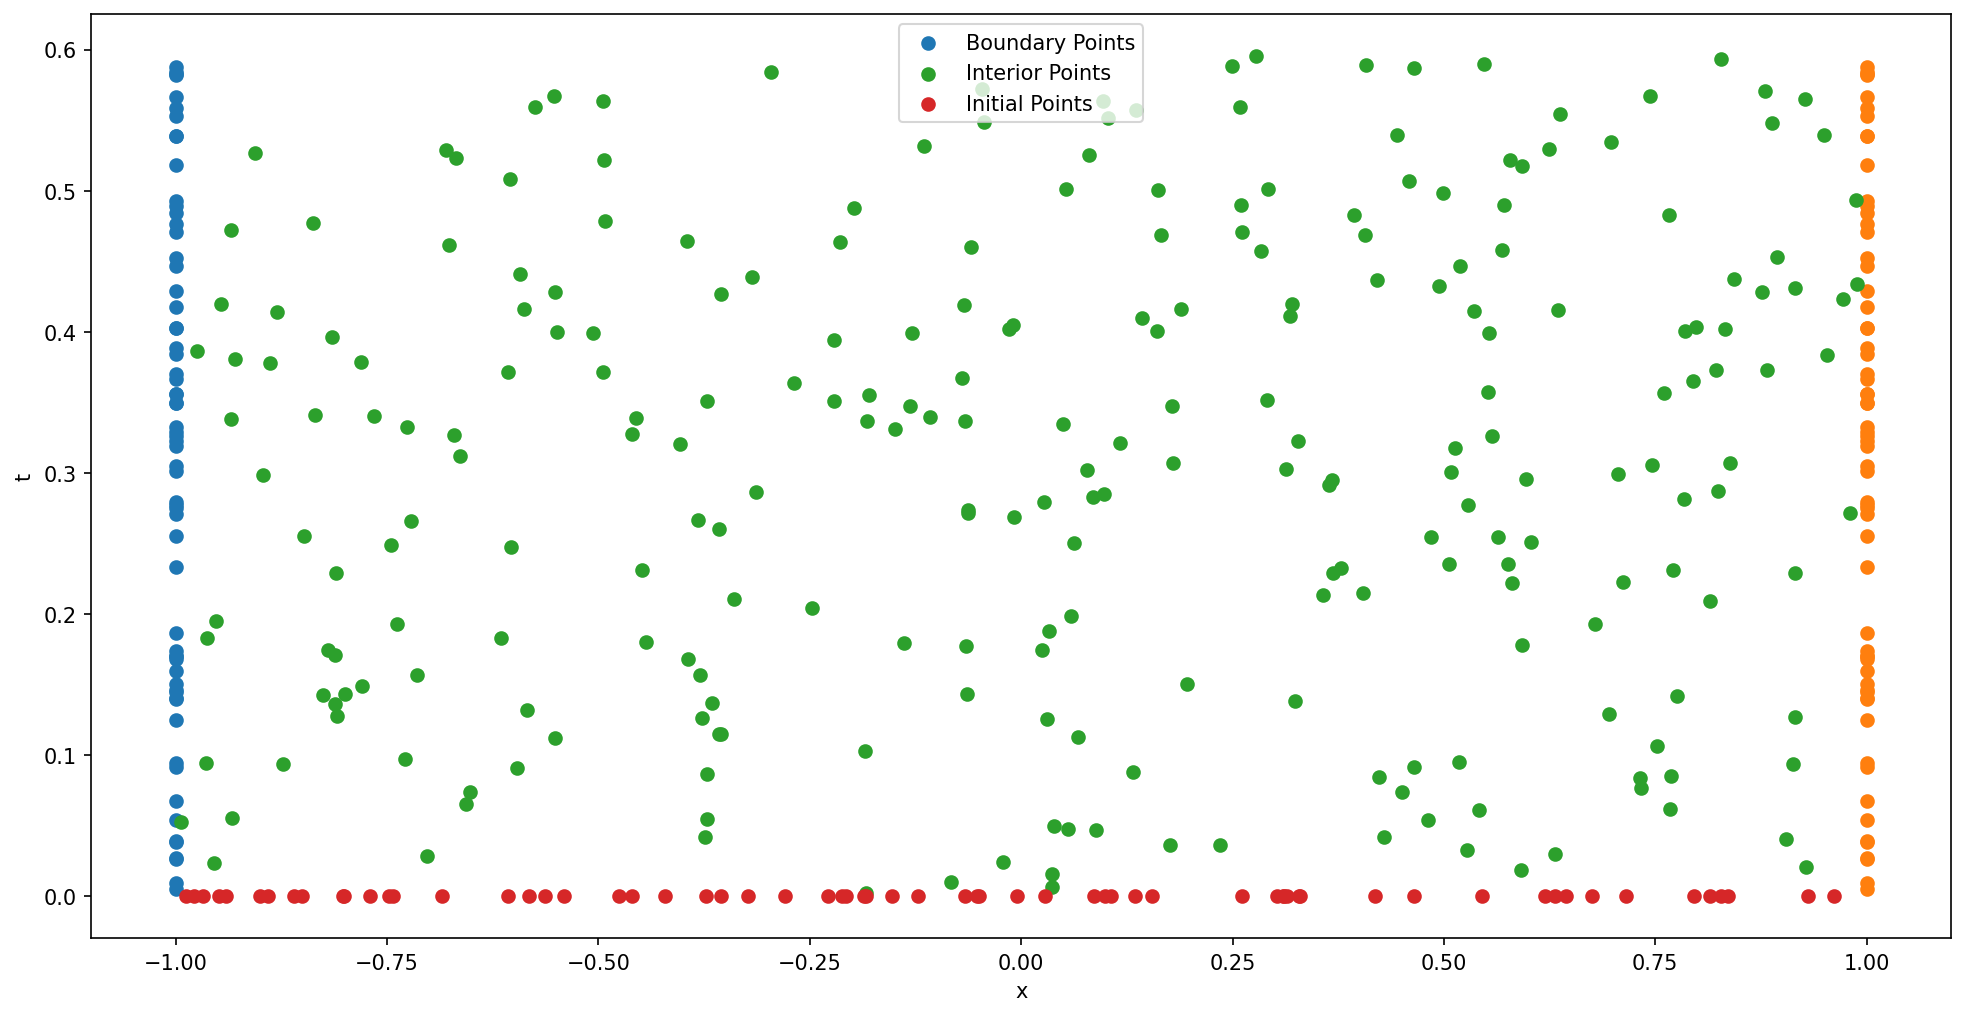

In [88]:
# Build points similar to the tutorial for visualization
t_min, t_max = 0.0, 0.6
x_min, x_max = -1.0, 1.0

# Interior points
t_int = np.random.uniform(t_min, t_max, size=(num_domain, 1))
x_int = np.random.uniform(x_min, x_max, size=(num_domain, 1))

# Spatial boundary points (x = -1 and x = 1)
t_sb = np.random.uniform(t_min, t_max, size=(num_boundary, 1))
x_sb_left = np.full_like(t_sb, x_min)
x_sb_right = np.full_like(t_sb, x_max)

# Initial points (t = 0)
x_tb = np.random.uniform(x_min, x_max, size=(num_initial, 1))
t_tb = np.zeros_like(x_tb)

plt.figure(figsize=(16, 8), dpi=150)
plt.scatter(x_sb_left, t_sb, label="Boundary Points")
plt.scatter(x_sb_right, t_sb)
plt.scatter(x_int, t_int, label="Interior Points")
plt.scatter(x_tb, t_tb, label="Initial Points")
plt.xlabel("x")
plt.ylabel("t")
plt.legend()
plt.show()

## 7) Neural Network

In [89]:
# Simple feedforward PINN
# Match baseline network size: 4 hidden layers, 20 neurons each
# Match baseline retrain_seed=42 (best-effort)
dde.config.set_random_seed(42)
net = dde.nn.FNN([2, 20, 20, 20, 20, 1], "tanh", "Glorot normal")

## 8) Model and Training

In [90]:
model = dde.Model(data, net)

# Match baseline: L-BFGS only, high iteration cap
dde.optimizers.set_LBFGS_options(
    maxiter=50000,
    maxfun=50000,
    maxcor=150,
    ftol=np.finfo(float).eps,
    gtol=np.finfo(float).eps,
)

# Loss is defined inside TimePDELog10 (log10 of weighted total)
model.compile("L-BFGS", loss="MSE")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.000487 s

Training model...

Cause: could not parse the source code of <function <lambda> at 0x00000248F31A4E50>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x00000248F31A4E50>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @

## 9) Training Loss (Log Scale)

C:\Users\Bioref\AppData\Local\Temp\ipykernel_8896\1616880361.py:10: RuntimeWarning: invalid value encountered in log10
  plt.plot(np.arange(1, len(total_loss) + 1), np.log10(total_loss), label="Train Loss")


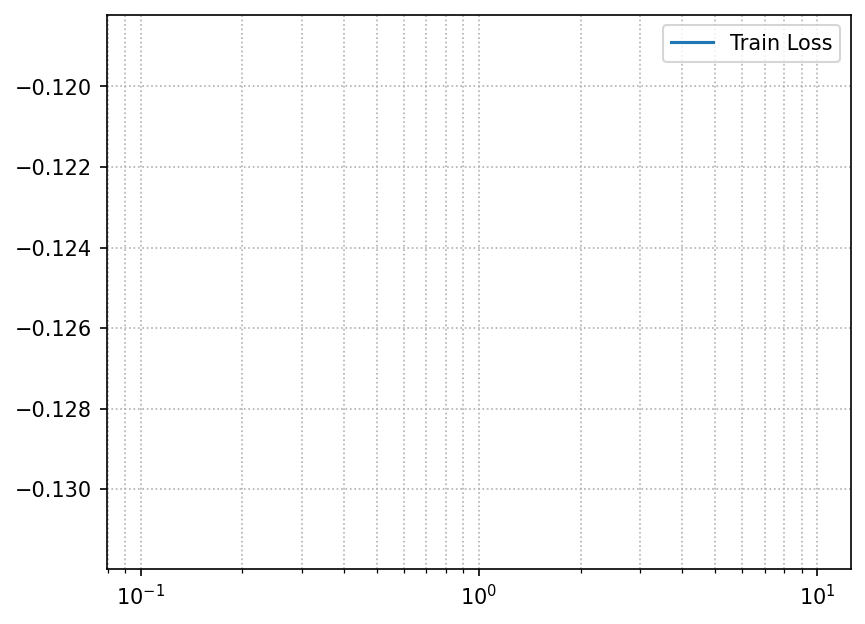

In [91]:
# Plot total training loss similar to the tutorial
loss_train = np.array(losshistory.loss_train)
if loss_train.ndim == 1:
    total_loss = loss_train
else:
    total_loss = loss_train.sum(axis=1)

plt.figure(dpi=150)
plt.grid(True, which="both", ls=":")
plt.plot(np.arange(1, len(total_loss) + 1), np.log10(total_loss), label="Train Loss")
plt.xscale("log")
plt.legend()
plt.show()

## 10) Exact vs Approximate Solution + L2 Relative Error

c:\Users\Bioref\anaconda3\envs\tf_clean\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+100001=100001. 
  warnings.warn(


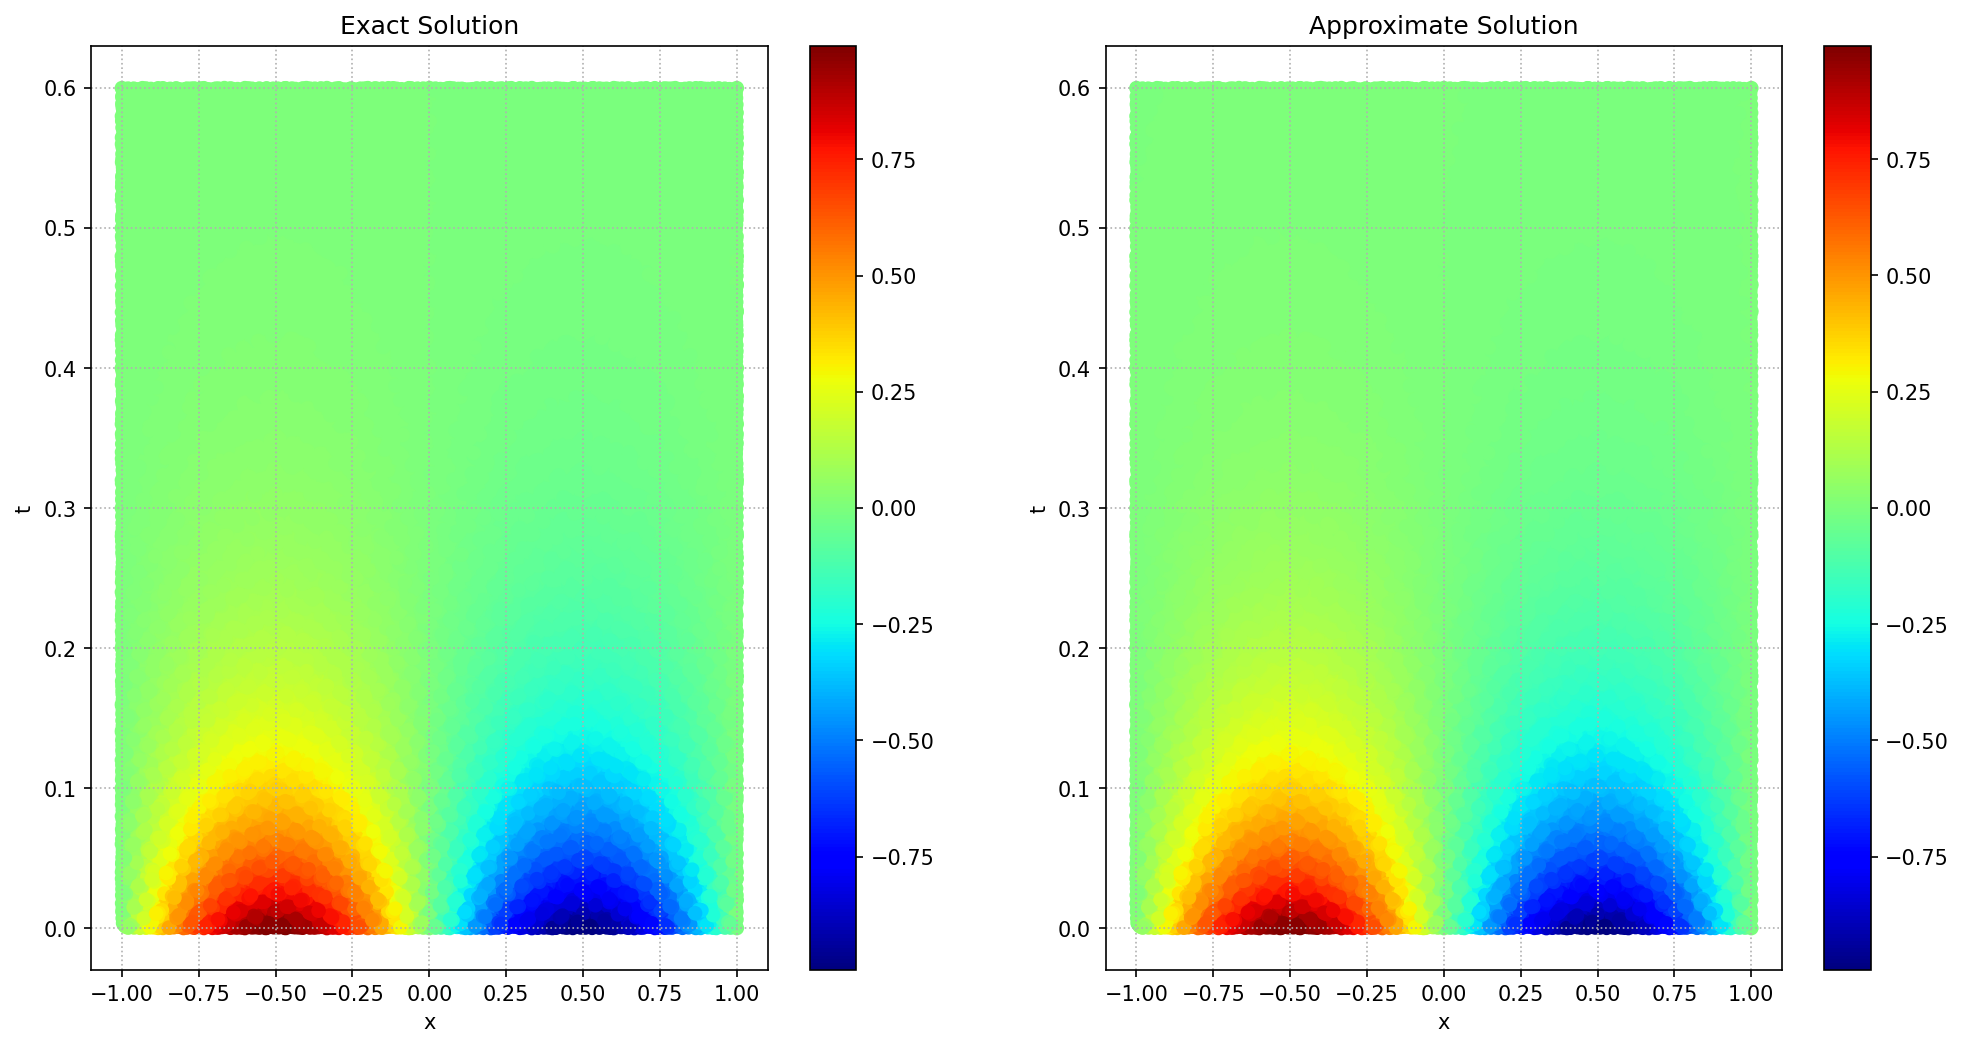

L2 Relative Error Norm: 0.1341%


In [92]:
# Exact solution for the chosen IC
def exact_solution(x, t):
    return -np.exp(-(np.pi ** 2) * t) * np.sin(np.pi * x)

# Sample points for visualization and L2 error (Sobol)
n_vis = 100000
X_vis = geomtime.random_points(n_vis, random="Sobol")
x_vis = X_vis[:, 0:1]
t_vis = X_vis[:, 1:2]

u_pred = model.predict(X_vis).reshape(-1)
u_exact = exact_solution(x_vis.reshape(-1), t_vis.reshape(-1))

fig, axs = plt.subplots(1, 2, figsize=(16, 8), dpi=150)
im1 = axs[0].scatter(x_vis, t_vis, c=u_exact, cmap="jet")
axs[0].set_xlabel("x")
axs[0].set_ylabel("t")
axs[0].set_title("Exact Solution")
axs[0].grid(True, which="both", ls=":")
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].scatter(x_vis, t_vis, c=u_pred, cmap="jet")
axs[1].set_xlabel("x")
axs[1].set_ylabel("t")
axs[1].set_title("Approximate Solution")
axs[1].grid(True, which="both", ls=":")
plt.colorbar(im2, ax=axs[1])

plt.show()

l2_rel = (np.mean((u_pred - u_exact) ** 2) / np.mean(u_exact ** 2)) ** 0.5 * 100
print(f"L2 Relative Error Norm: {l2_rel:.4f}%")